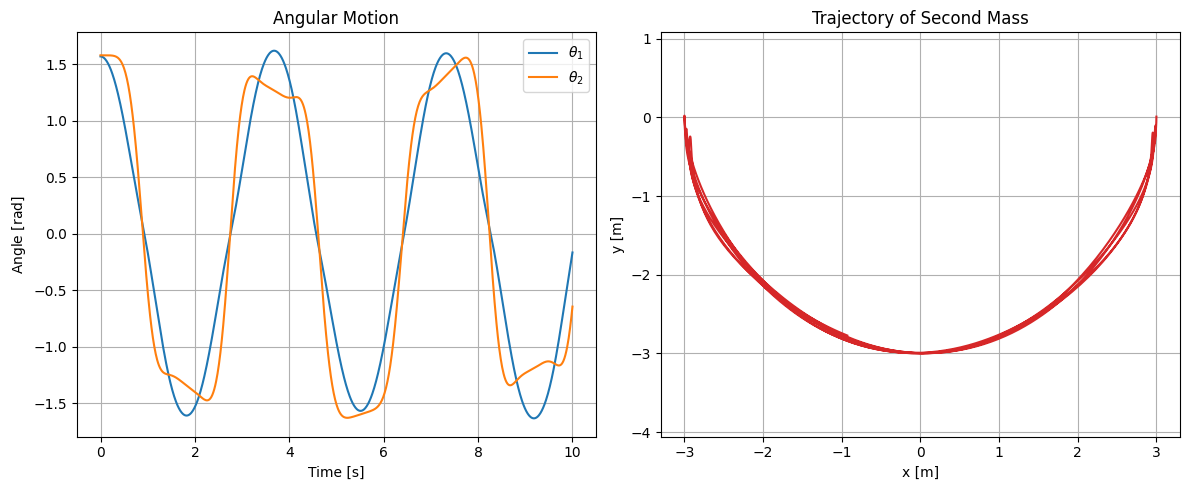

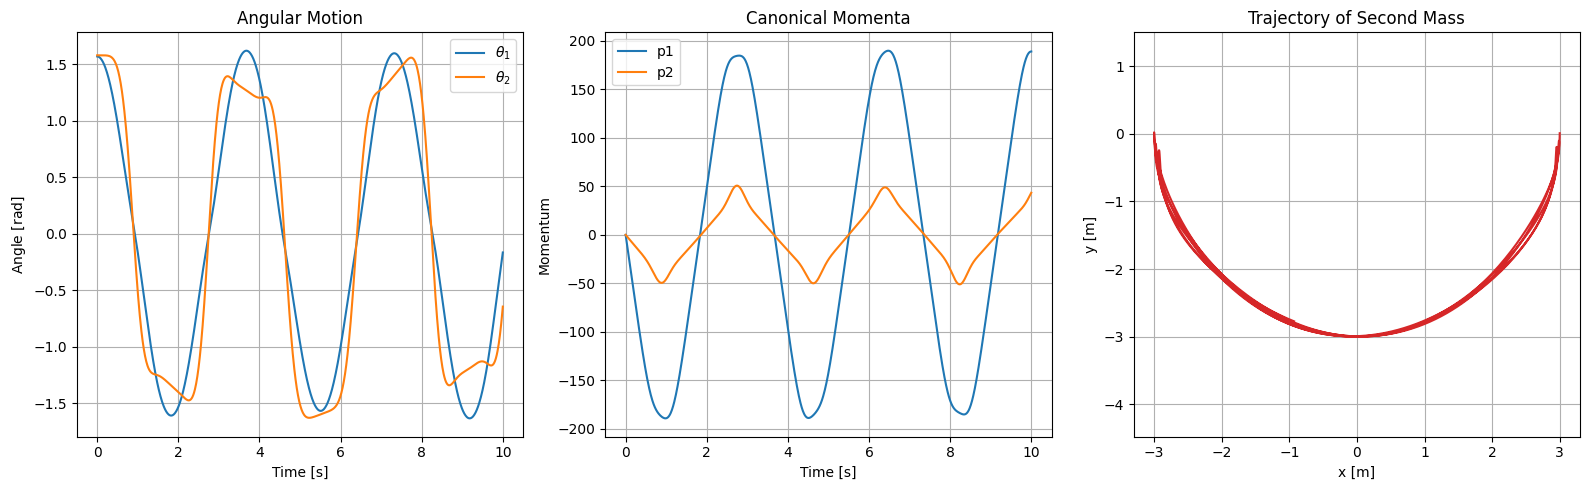

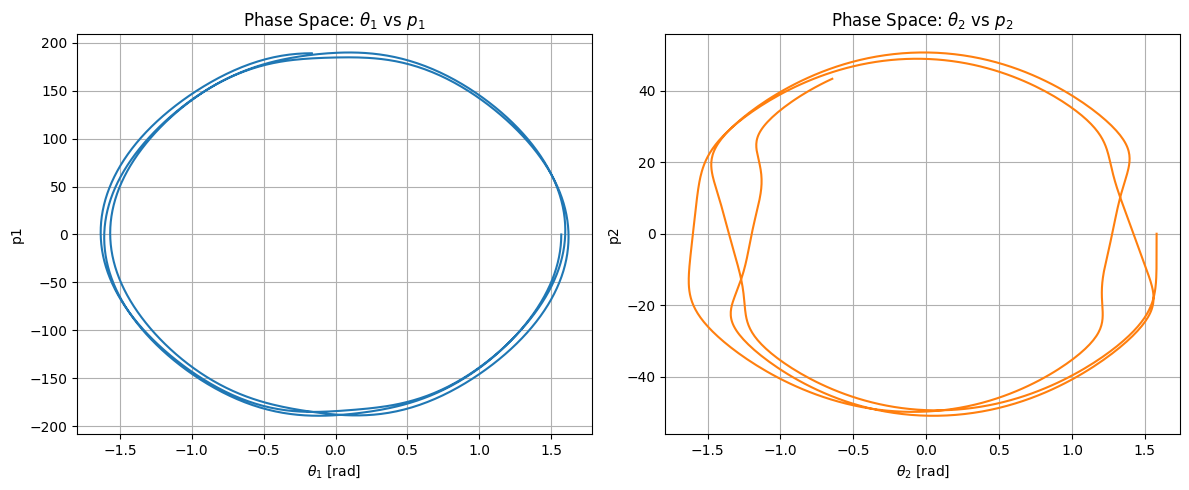

In [3]:
from dynamics import load_config, solve_lagrangian, solve_hamiltonian
from visualization import plot_solution, plot_phase_space, plot_energy

config = load_config("simulation_input_card.json")

# define parameters of the simulation
m1 = config["m1"]
m2 = config["m2"]
L1 = config["L1"]
L2 = config["L2"]
g = config["g"]
theta1_0 = config["theta1_0"]
omega1_0 = config["omega1_0"]
theta2_0 = config["theta2_0"]
omega2_0 = config["omega2_0"]
t_max = config["t_max"]
dt = config["dt"]

# Compute numerical solutions using Runge-Kutta
solution_l = solve_lagrangian(config, method="rk4")
solution_h = solve_hamiltonian(config, method="rk4")
plot_solution(solution_l)
plot_solution(solution_h)
plot_phase_space(solution_h)

In [4]:
# Build neural network dataset 
import torch
from neural_networks.dataset import build_training_dataset, save_dataset

# Number of different initial conditions from which the training dataset is generated
num_trajectories = 200

# Generate dataset
dataset = build_training_dataset(
    num_trajectories=num_trajectories, 
    t_max = t_max, 
    dt = dt, 
    seed = 42, 
    val_fraction=0.2,
    m1 = m1, 
    m2 = m2, 
    L1 = L1, 
    L2 = L2, 
    g = g, 
    omega_scale = 2.0,
    as_torch = True, 
)

path = "neural_networks/data/double_pendulum_dataset.pt"
# Save dataset
save_dataset(dataset, path)

### Vector-field Neural Network

In [8]:
from neural_networks.training import train_vector_field_model

# Train vector field neural network
model, history = train_vector_field_model(
    dataset,
    epochs=200,
    batch_size=512,
    lr=1e-3,
    hidden_dim=128,
    num_hidden_layers=3,
    device="cpu",
    checkpoint_path="neural_networks/checkpoints/vector_field.pt",
)

Training direct vector-field neural network.
Device: cpu
Model:  3 hidden layers, width 128
Epoch    1/200 train_loss=4.990489e-01 val_loss=4.103119e-01 best_val_loss=4.103119e-01
Epoch    2/200 train_loss=3.752445e-01 val_loss=3.649655e-01 best_val_loss=3.649655e-01
Epoch    3/200 train_loss=3.574477e-01 val_loss=3.507872e-01 best_val_loss=3.507872e-01
Epoch    4/200 train_loss=3.474764e-01 val_loss=3.461581e-01 best_val_loss=3.461581e-01
Epoch    5/200 train_loss=3.412774e-01 val_loss=3.407868e-01 best_val_loss=3.407868e-01
Epoch    6/200 train_loss=3.364288e-01 val_loss=3.354500e-01 best_val_loss=3.354500e-01
Epoch    7/200 train_loss=3.324419e-01 val_loss=3.304697e-01 best_val_loss=3.304697e-01
Epoch    8/200 train_loss=3.296179e-01 val_loss=3.294700e-01 best_val_loss=3.294700e-01
Epoch    9/200 train_loss=3.254391e-01 val_loss=3.243724e-01 best_val_loss=3.243724e-01
Epoch   10/200 train_loss=3.197450e-01 val_loss=3.146006e-01 best_val_loss=3.146006e-01
Epoch   11/200 train_loss=3.

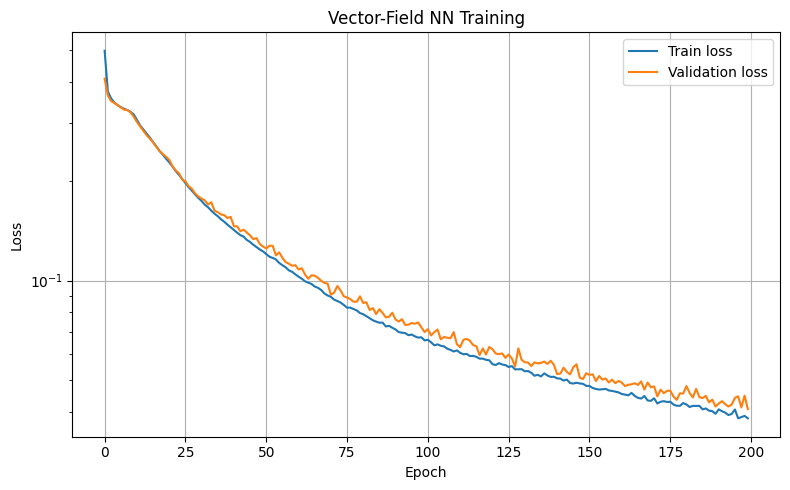

In [9]:
# Plot the loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.semilogy(history["train_loss"], label="Train loss")
plt.semilogy(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vector-Field NN Training")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

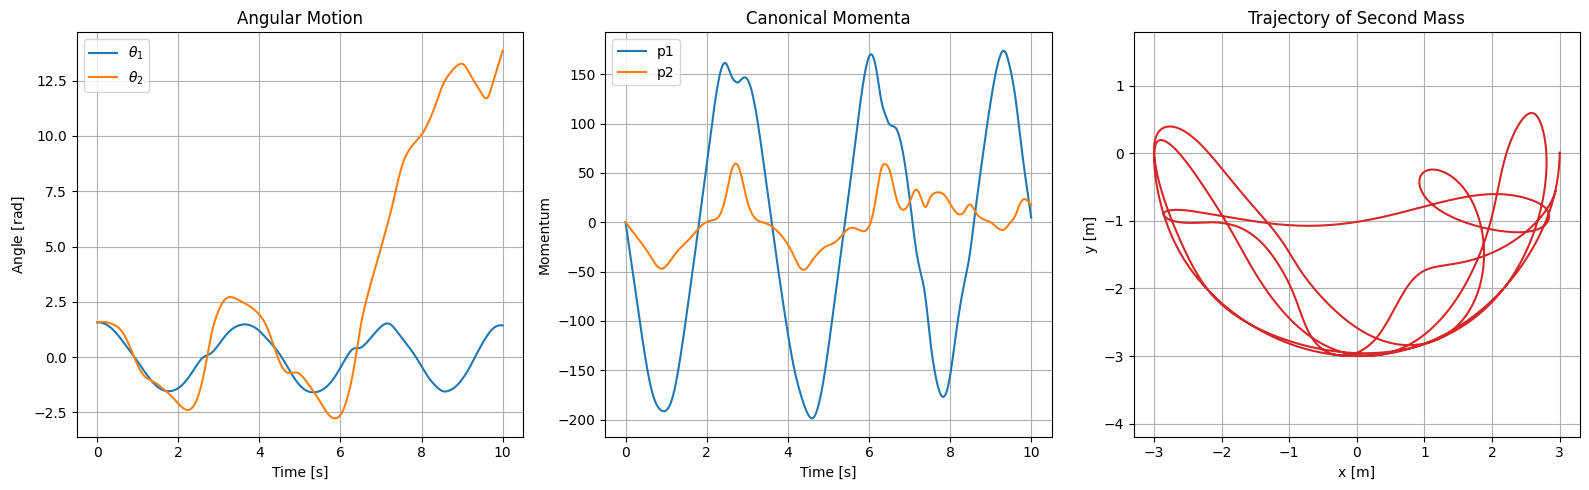

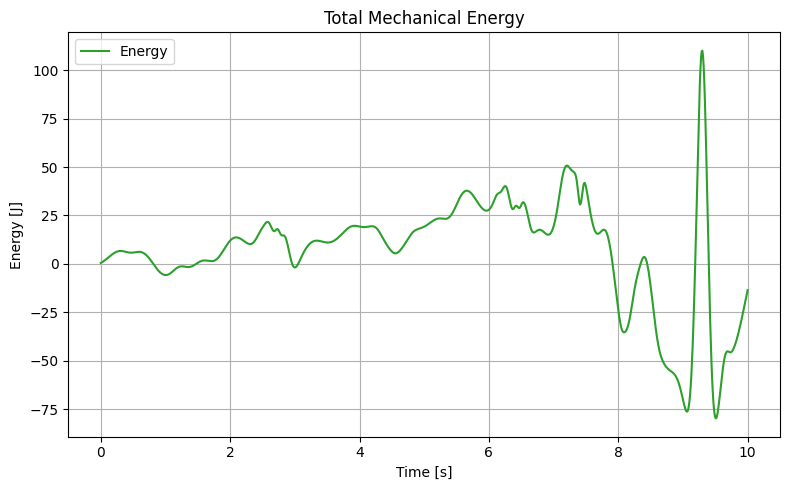

In [10]:
from neural_networks.rollout import rollout_vector_field_checkpoint, rollout_hnn_checkpoint
import plotting

solution_nn = rollout_vector_field_checkpoint(
    "neural_networks/checkpoints/vector_field.pt",
    config={"t_max": 10.0, "dt": 0.01},
    device="cpu",
)

# Plot vector-field NN solution 
plot_solution(solution_nn)
# Plot energy of vector-field NN solution 
plot_energy(solution_nn)

We can see that the vector field NN does not learn the trajectories very well and energy conservation is not really respected.

### Hamiltonian Neural Network

We therefore try an Hamiltonian neural network approach (https://greydanus.github.io/2019/05/15/hamiltonian-nns/?utm_source=chatgpt.com)

In [11]:
from neural_networks.training import train_hnn_model

modelhnn, history = train_hnn_model(
    dataset,
    epochs=200,
    batch_size=512,
    lr=1e-3,
    hidden_dim=128,
    num_hidden_layers=3,
    device="cpu",
    checkpoint_path="neural_networks/checkpoints/hamiltonian_nn.pt",
)

Training Hamiltonian neural network.
Device: cpu
Model:  3 hidden layers, width 128
Epoch    1/200 train_loss=5.446949e-01 val_loss=2.728941e-01 best_val_loss=2.728941e-01
Epoch    2/200 train_loss=2.034140e-01 val_loss=1.559165e-01 best_val_loss=1.559165e-01
Epoch    3/200 train_loss=1.369461e-01 val_loss=1.194934e-01 best_val_loss=1.194934e-01
Epoch    4/200 train_loss=1.121097e-01 val_loss=1.090861e-01 best_val_loss=1.090861e-01
Epoch    5/200 train_loss=9.367529e-02 val_loss=8.936314e-02 best_val_loss=8.936314e-02
Epoch    6/200 train_loss=7.488930e-02 val_loss=6.545844e-02 best_val_loss=6.545844e-02
Epoch    7/200 train_loss=6.129384e-02 val_loss=6.056401e-02 best_val_loss=6.056401e-02
Epoch    8/200 train_loss=4.986553e-02 val_loss=4.415866e-02 best_val_loss=4.415866e-02
Epoch    9/200 train_loss=4.145498e-02 val_loss=3.830997e-02 best_val_loss=3.830997e-02
Epoch   10/200 train_loss=3.672194e-02 val_loss=3.419864e-02 best_val_loss=3.419864e-02
Epoch   11/200 train_loss=3.072575e-

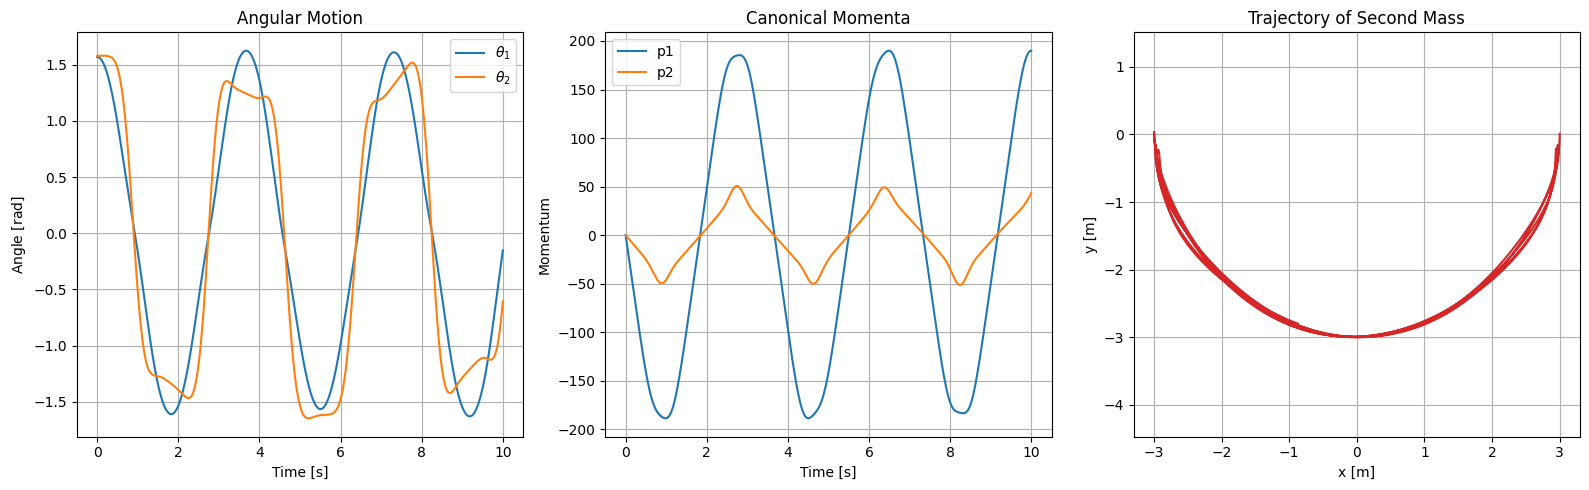

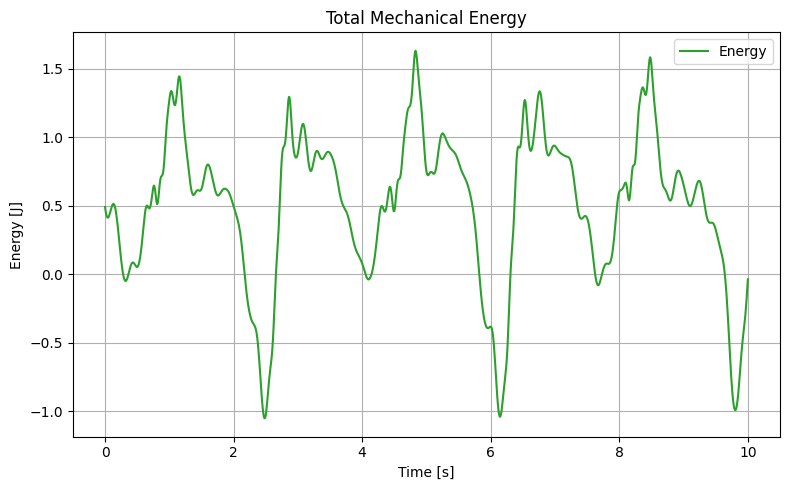

In [12]:
solution_hnn = rollout_hnn_checkpoint(
    "neural_networks/checkpoints/hamiltonian_nn.pt",
    config={"t_max": 10.0, "dt": 0.01},
    device="cpu",
)

# Plot vector-field NN solution 
plot_solution(solution_hnn)
# Plot energy of vector-field NN solution 
plot_energy(solution_hnn)

### Comparisons

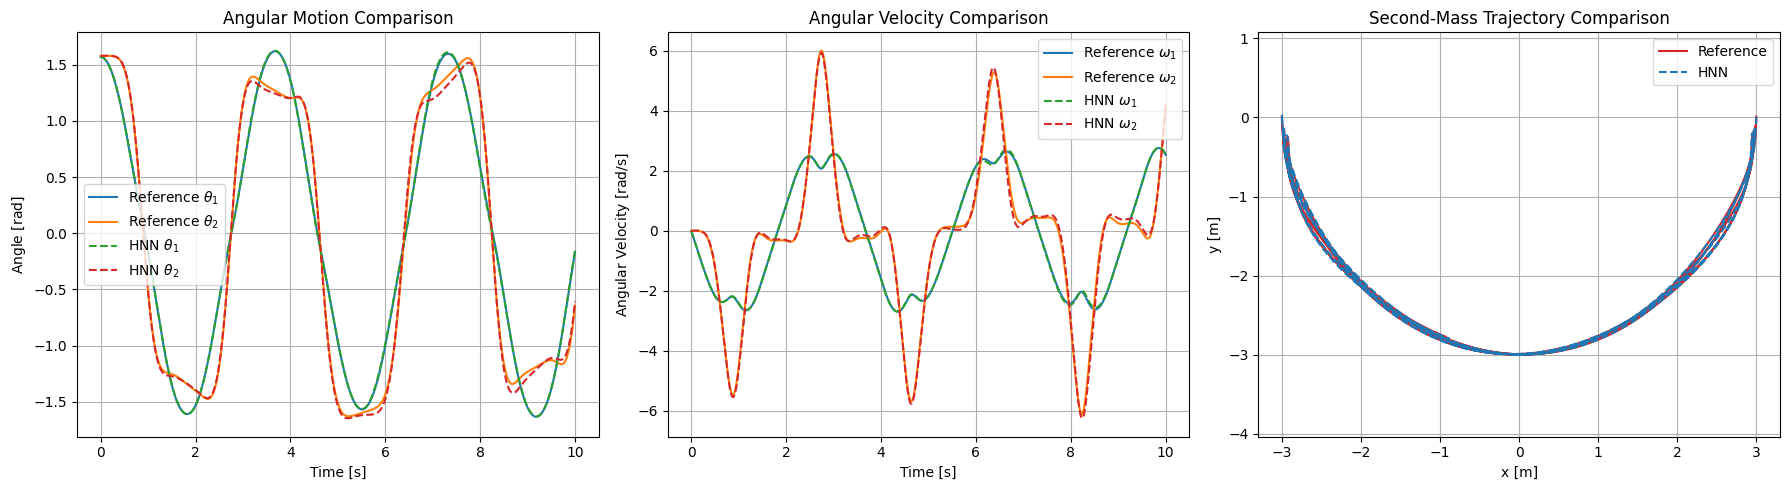

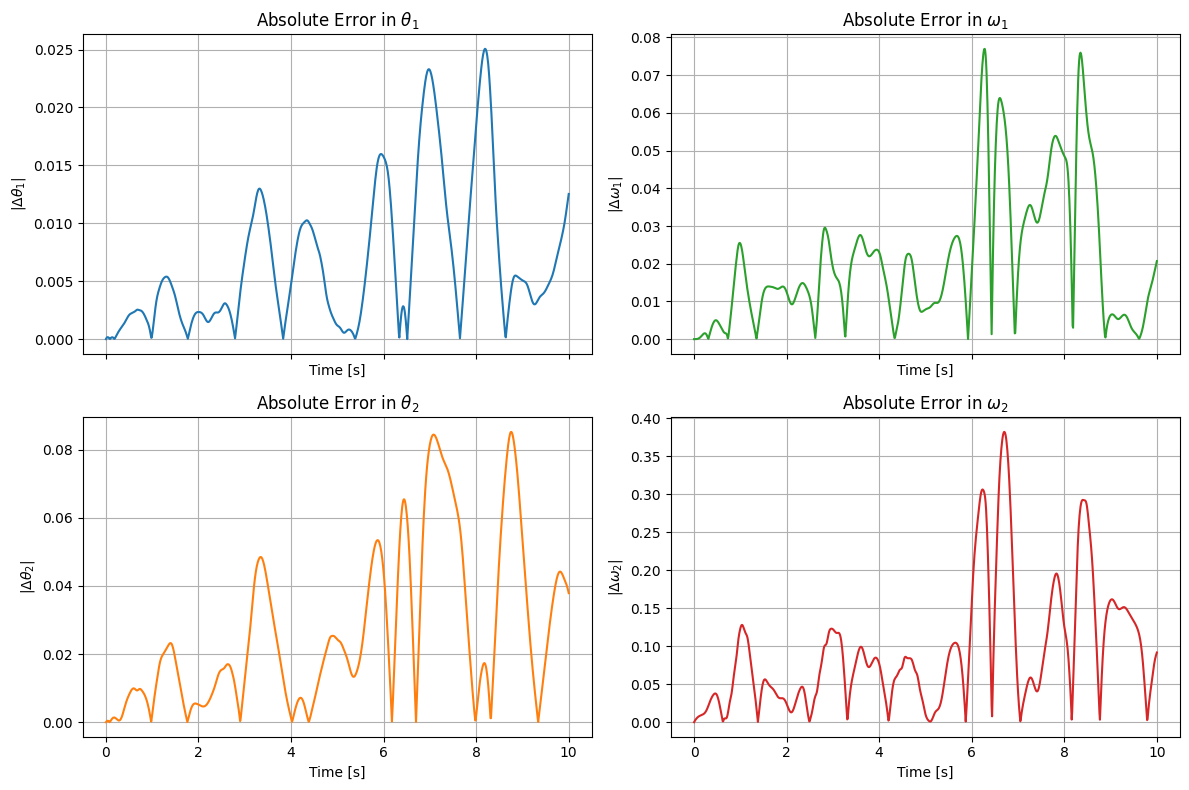

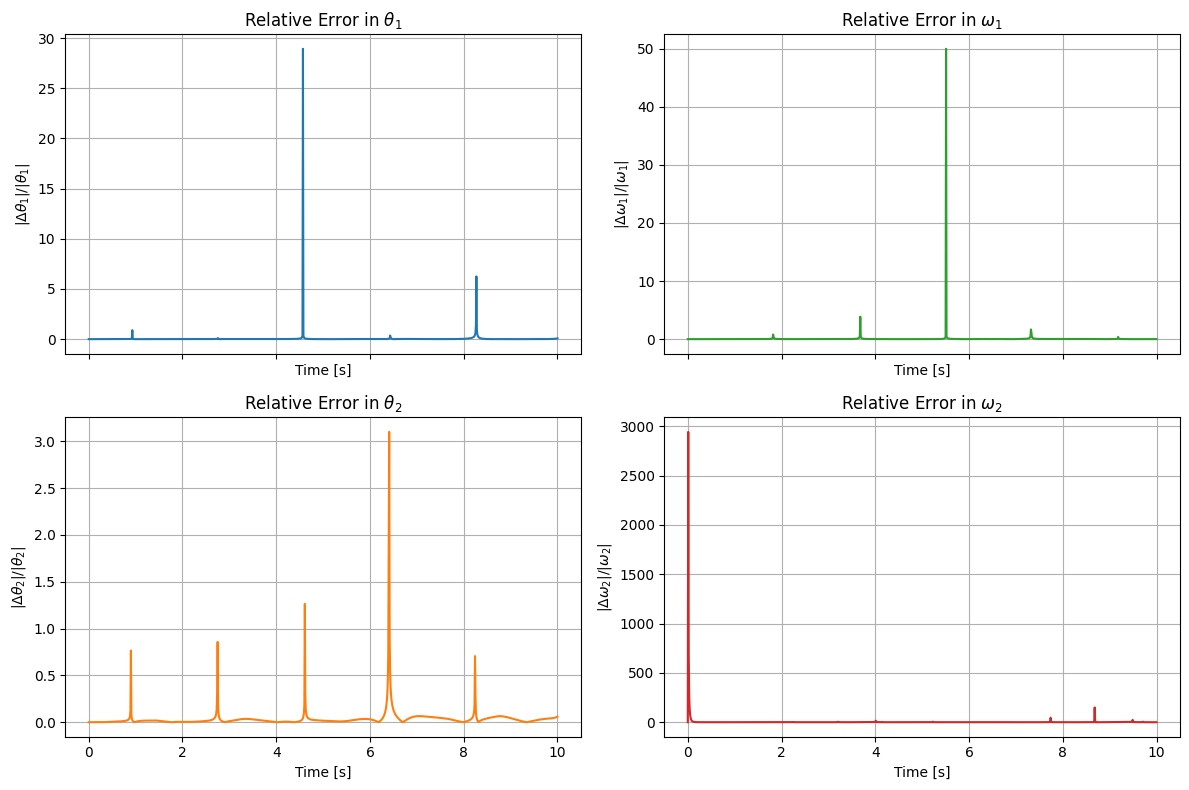

In [13]:
from plotting import plot_comparison, plot_comparison_error, plot_comparison_relative_error

plot_comparison(solution_h, solution_hnn, label_a="Reference", label_b="HNN")
plot_comparison_error(solution_h, solution_hnn)
plot_comparison_relative_error(solution_h, solution_hnn)

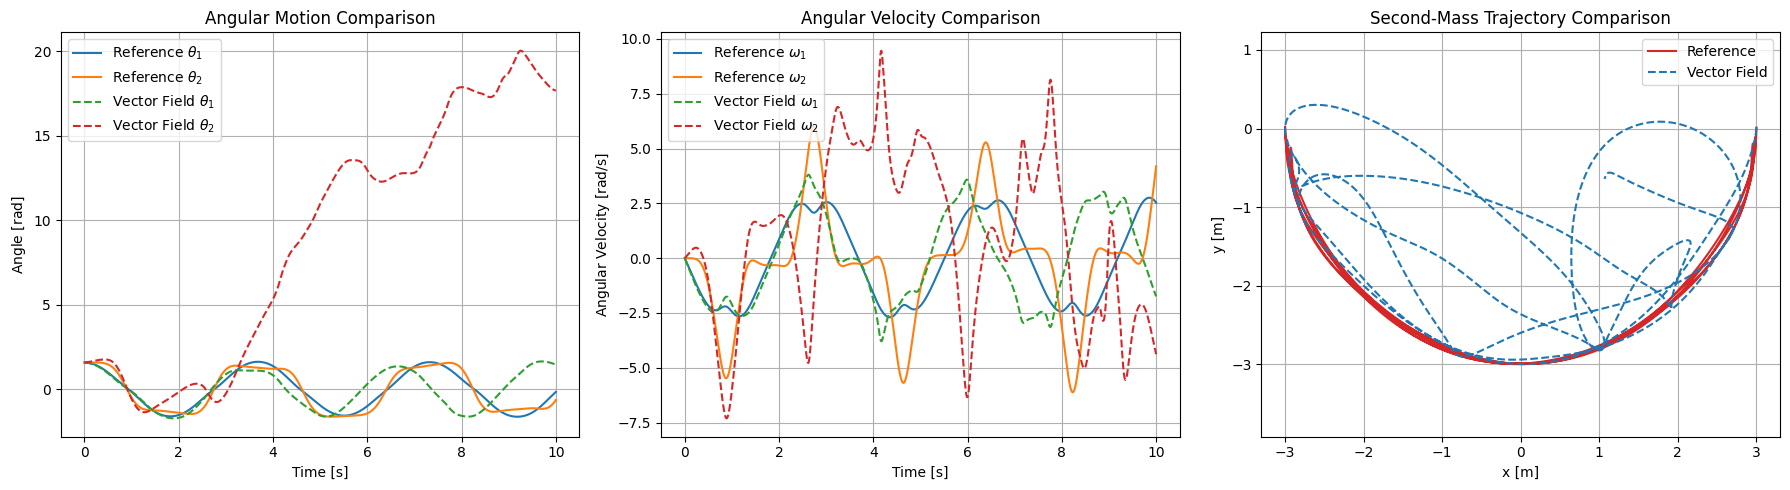

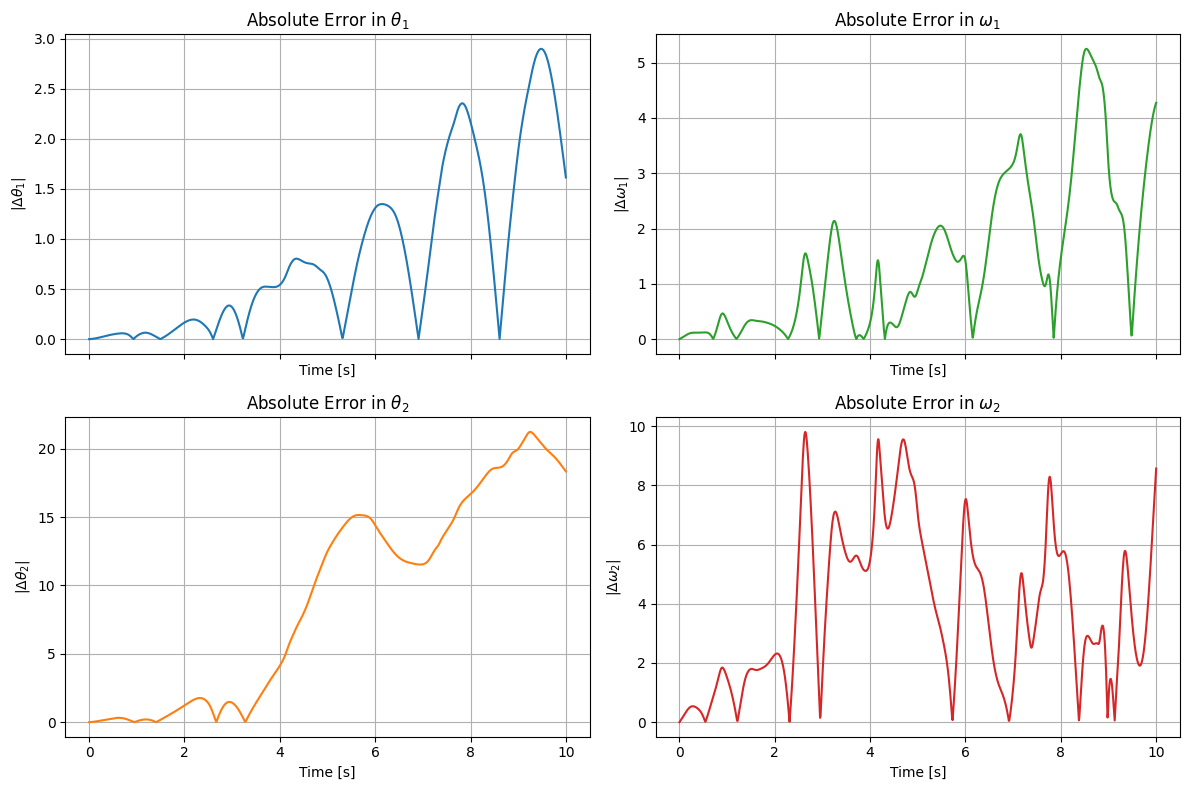

In [ ]:
# Compare the vector-field NN solution and the real solution 

plot_comparison(solution_h, solution_nn, label_a="Reference", label_b="Vector Field")
plot_comparison_error(solution_h, solution_nn)

Conclusions: as expected, the Hamiltonian Neural Network works much better!